<a href="https://colab.research.google.com/github/Anjneya3/scaling-succotash/blob/main/Untitled12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🚀 SETTING UP DATASETS...
   ✅ Speech & Noise already present.
   ✅ Music found (5 files). Starting training...

🔄 Processing Audio Files...
   Processing music...
   Processing speech...
   Processing noise...
   Training on 405 files...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ MODEL TRAINED SUCCESSFULLY!

 🧪 TEST TIME: UPLOAD A NEW FILE


Saving Penguin_Popstar__Chill__Feb_18_2026_833_PM.wav to Penguin_Popstar__Chill__Feb_18_2026_833_PM.wav

Analyzing Penguin_Popstar__Chill__Feb_18_2026_833_PM.wav...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


/tmp/ipython-input-1363739272.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=CLASSES, y=probs, palette=['blue', 'green', 'red'])


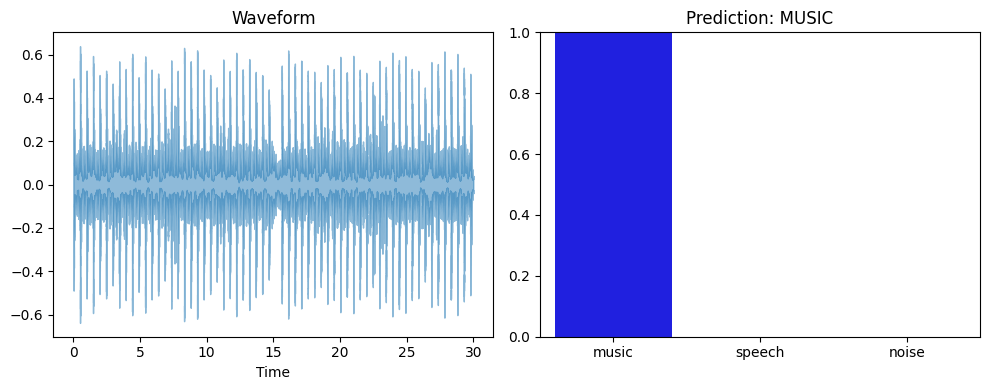

🎯 RESULT: MUSIC (100.0% confidence)


In [11]:
# ==========================================
#   AUDIO CLASSIFIER: ROBUST VERSION
# ==========================================

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical
from google.colab import files

# --- PART 1: INSTALL LIBRARIES ---
try:
    import librosa
    import librosa.display
except ImportError:
    print("Installing libraries...")
    !pip install librosa matplotlib seaborn resampy -q
    import librosa
    import librosa.display

# --- PART 2: SMART DATA SETUP ---
print("\n🚀 SETTING UP DATASETS...")

# 1. Define Paths
BASE_DIR = 'data'
SPEECH_DIR = os.path.join(BASE_DIR, 'speech')
NOISE_DIR = os.path.join(BASE_DIR, 'noise')
MUSIC_DIR = os.path.join(BASE_DIR, 'music')

for d in [SPEECH_DIR, NOISE_DIR, MUSIC_DIR]:
    os.makedirs(d, exist_ok=True)

# 2. Download & Locate Data
if len(os.listdir(SPEECH_DIR)) < 10:
    print("   Downloading Speech & Noise data...")
    dataset_url = "http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"
    # Download to local cache
    zip_path = tf.keras.utils.get_file(
        origin=dataset_url,
        fname='mini_speech_commands.zip',
        extract=True,
        cache_dir='.', cache_subdir='raw_data'
    )

    # --- ROBUST SEARCH FOR FOLDERS ---
    print("   Locating folders...")
    raw_root = os.path.dirname(zip_path) # Start searching where we downloaded

    found_speech_dir = None
    found_noise_dir = None

    # Walk through all folders to find 'up' (Speech) and '_background_noise_' (Noise)
    for root, dirs, files in os.walk(raw_root):
        if 'up' in dirs and 'down' in dirs:
            found_speech_dir = root
        if '_background_noise_' in dirs:
            found_noise_dir = os.path.join(root, '_background_noise_')

    # --- COPY SPEECH ---
    if found_speech_dir:
        words = ['up', 'down', 'left', 'right', 'yes', 'no', 'go', 'stop']
        for word in words:
            word_path = os.path.join(found_speech_dir, word)
            if os.path.exists(word_path):
                # Copy 50 files
                for f in os.listdir(word_path)[:50]:
                    shutil.copy(os.path.join(word_path, f), os.path.join(SPEECH_DIR, f"{word}_{f}"))
        print("   ✅ Speech files ready.")
    else:
        print("   ❌ Error: Could not find speech folders (up/down).")

    # --- COPY NOISE ---
    if found_noise_dir:
        for f in os.listdir(found_noise_dir):
            if f.endswith('.wav'):
                shutil.copy(os.path.join(found_noise_dir, f), os.path.join(NOISE_DIR, f))
        print("   ✅ Noise files ready.")
    else:
        print("   ❌ Error: Could not find '_background_noise_' folder.")

else:
    print("   ✅ Speech & Noise already present.")

# 3. CHECK FOR MUSIC
music_files = [f for f in os.listdir(MUSIC_DIR) if f.endswith('.wav') or f.endswith('.mp3')]
if len(music_files) < 5:
    print("\n" + "="*60)
    print("🔴 ACTION REQUIRED: UPLOAD MUSIC FILES")
    print("="*60)
    print(f"1. Open the folder icon 📁 on the left.")
    print(f"2. Navigate to: data -> music")
    print(f"3. DRAG & DROP 5-10 song files (.wav or .mp3) there.")
    print(f"4. RUN THIS CELL AGAIN.")
    print("="*60)
    # Stop execution safely
    raise SystemExit("Stopping script so you can upload music.")

print(f"   ✅ Music found ({len(music_files)} files). Starting training...")


# --- PART 3: TRAIN MODEL ---
CLASSES = ['music', 'speech', 'noise']
N_MFCC = 40

def extract_features(file_path):
    try:
        # Load audio (Limit to 30s)
        audio, sample_rate = librosa.load(file_path, duration=30)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=N_MFCC)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        print(f"   Error reading {file_path}: {e}")
        return None

X_train, y_train = [], []
print("\n🔄 Processing Audio Files...")

for label in CLASSES:
    folder = os.path.join(BASE_DIR, label)
    files_in_folder = os.listdir(folder)
    print(f"   Processing {label}...")

    for f in files_in_folder:
        if f.endswith('.wav') or f.endswith('.mp3'):
            feat = extract_features(os.path.join(folder, f))
            if feat is not None:
                X_train.append(feat)
                y_train.append(CLASSES.index(label))

X_train = np.array(X_train)
y_train = to_categorical(np.array(y_train), num_classes=3)

# Build Model
model = Sequential([
    Dense(256, input_shape=(N_MFCC,), activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
print(f"   Training on {len(X_train)} files...")
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)
print("✅ MODEL TRAINED SUCCESSFULLY!")


# --- PART 4: TEST ---
print("\n" + "="*40)
print(" 🧪 TEST TIME: UPLOAD A NEW FILE")
print("="*40)

uploaded = files.upload()

for fn in uploaded.keys():
    print(f"\nAnalyzing {fn}...")

    feat = extract_features(fn)
    if feat is not None:
        feat = feat.reshape(1, -1)
        probs = model.predict(feat)[0]
        pred_class = CLASSES[np.argmax(probs)]

        # Visualize
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        y, sr = librosa.load(fn, duration=30)
        librosa.display.waveshow(y, sr=sr, alpha=0.5)
        plt.title("Waveform")

        plt.subplot(1, 2, 2)
        sns.barplot(x=CLASSES, y=probs, palette=['blue', 'green', 'red'])
        plt.ylim(0, 1)
        plt.title(f"Prediction: {pred_class.upper()}")
        plt.tight_layout()
        plt.show()

        print(f"🎯 RESULT: {pred_class.upper()} ({np.max(probs)*100:.1f}% confidence)")